<a href="https://www.kaggle.com/code/lalit7881/student-academic-performance-eda-99?scriptVersionId=319979189" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/itszubi/students-academic-performance-dataset/StudentPerformanceFactors.csv


## Loading dataset

In [2]:
df = pd.read_csv("/kaggle/input/datasets/itszubi/students-academic-performance-dataset/StudentPerformanceFactors.csv")

In [3]:
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [4]:
df.tail()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
6602,25,69,High,Medium,No,7,76,Medium,Yes,1,High,Medium,Public,Positive,2,No,High School,Near,Female,68
6603,23,76,High,Medium,No,8,81,Medium,Yes,3,Low,High,Public,Positive,2,No,High School,Near,Female,69
6604,20,90,Medium,Low,Yes,6,65,Low,Yes,3,Low,Medium,Public,Negative,2,No,Postgraduate,Near,Female,68
6605,10,86,High,High,Yes,6,91,High,Yes,2,Low,Medium,Private,Positive,3,No,High School,Far,Female,68
6606,15,67,Medium,Low,Yes,9,94,Medium,Yes,0,Medium,Medium,Public,Positive,4,No,Postgraduate,Near,Male,64


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence              6607 non-null   obje

In [6]:
df.describe()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


In [7]:
df.isnull()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6602,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
6603,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
6604,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
6605,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [8]:
df.isnull().sum()

Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            67
Gender                         0
Exam_Score                     0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.dtypes

Hours_Studied                  int64
Attendance                     int64
Parental_Involvement          object
Access_to_Resources           object
Extracurricular_Activities    object
Sleep_Hours                    int64
Previous_Scores                int64
Motivation_Level              object
Internet_Access               object
Tutoring_Sessions              int64
Family_Income                 object
Teacher_Quality               object
School_Type                   object
Peer_Influence                object
Physical_Activity              int64
Learning_Disabilities         object
Parental_Education_Level      object
Distance_from_Home            object
Gender                        object
Exam_Score                     int64
dtype: object

In [11]:
df.shape

(6607, 20)

In [12]:
df.columns

Index(['Hours_Studied', 'Attendance', 'Parental_Involvement',
       'Access_to_Resources', 'Extracurricular_Activities', 'Sleep_Hours',
       'Previous_Scores', 'Motivation_Level', 'Internet_Access',
       'Tutoring_Sessions', 'Family_Income', 'Teacher_Quality', 'School_Type',
       'Peer_Influence', 'Physical_Activity', 'Learning_Disabilities',
       'Parental_Education_Level', 'Distance_from_Home', 'Gender',
       'Exam_Score'],
      dtype='object')

In [13]:
df.nunique()

Hours_Studied                 41
Attendance                    41
Parental_Involvement           3
Access_to_Resources            3
Extracurricular_Activities     2
Sleep_Hours                    7
Previous_Scores               51
Motivation_Level               3
Internet_Access                2
Tutoring_Sessions              9
Family_Income                  3
Teacher_Quality                3
School_Type                    2
Peer_Influence                 3
Physical_Activity              7
Learning_Disabilities          2
Parental_Education_Level       3
Distance_from_Home             3
Gender                         2
Exam_Score                    45
dtype: int64

## EDA

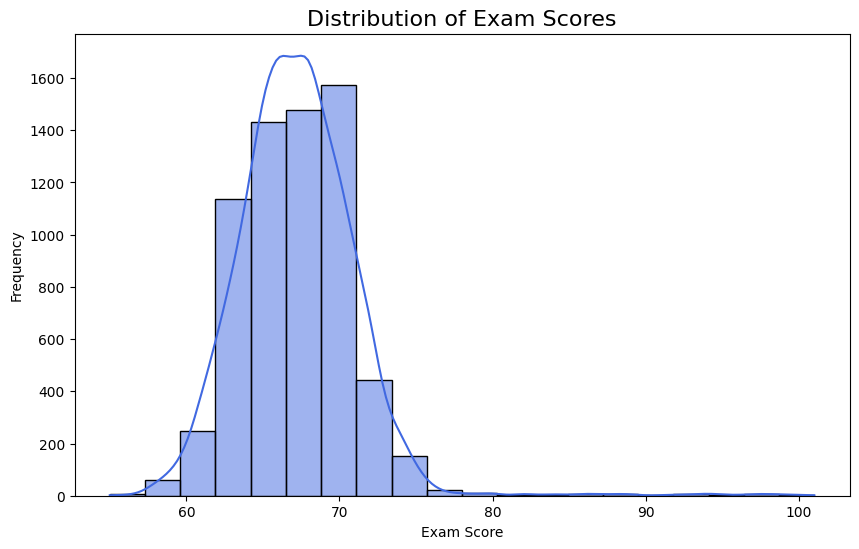

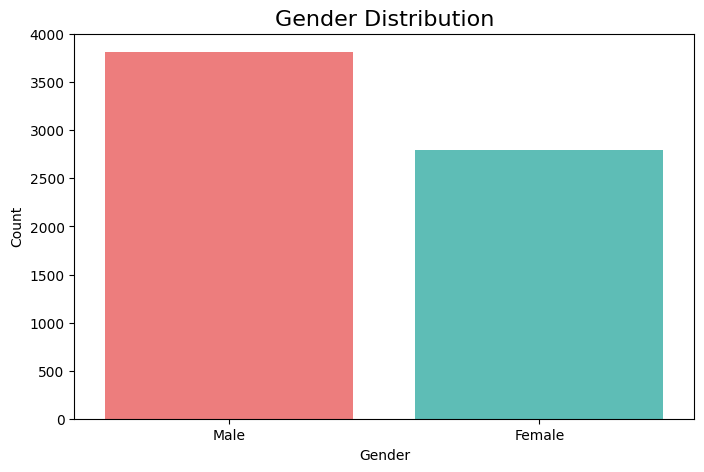

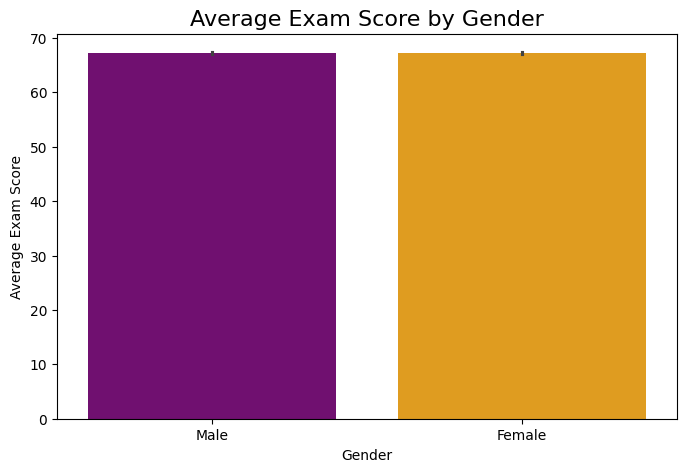

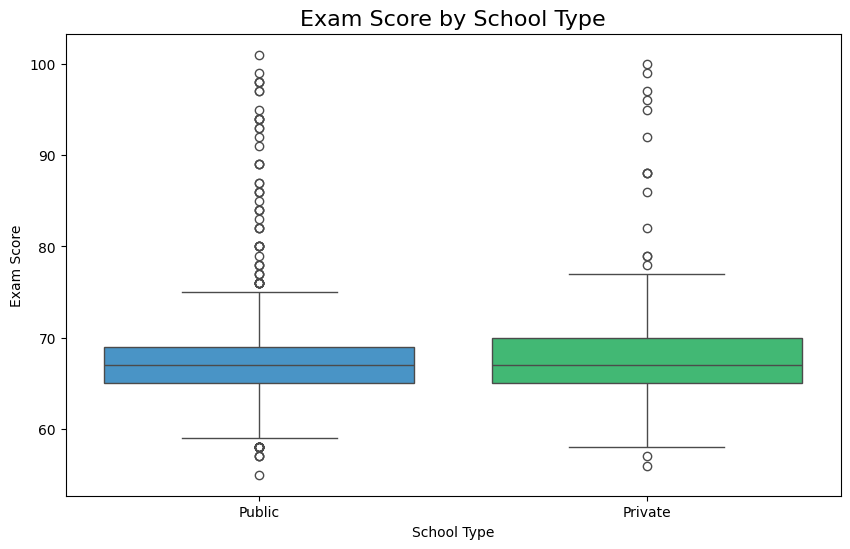

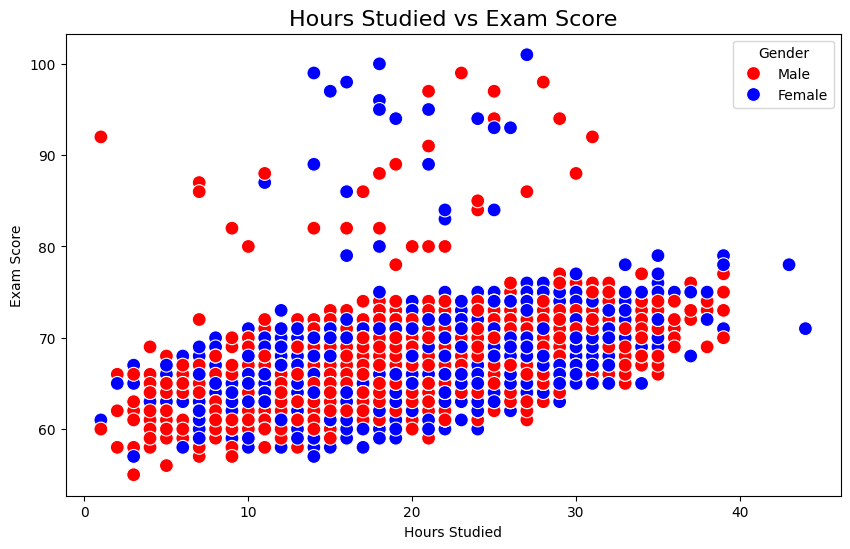

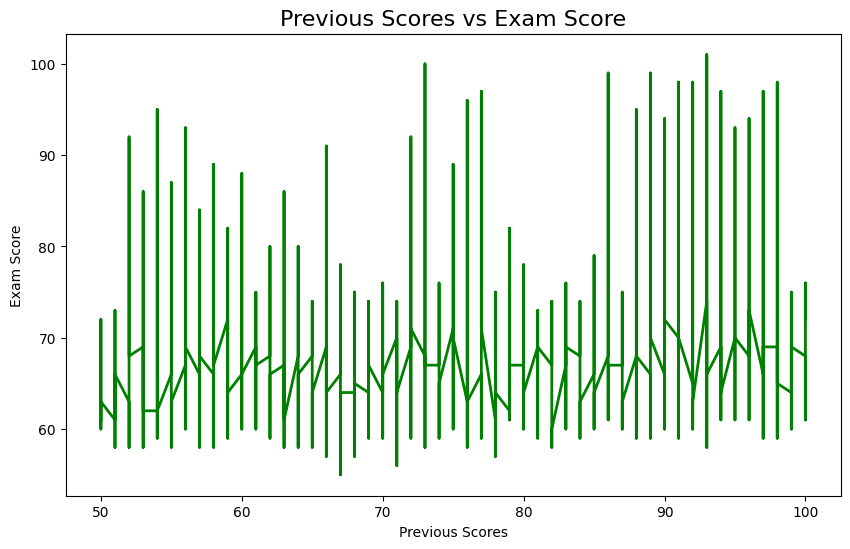

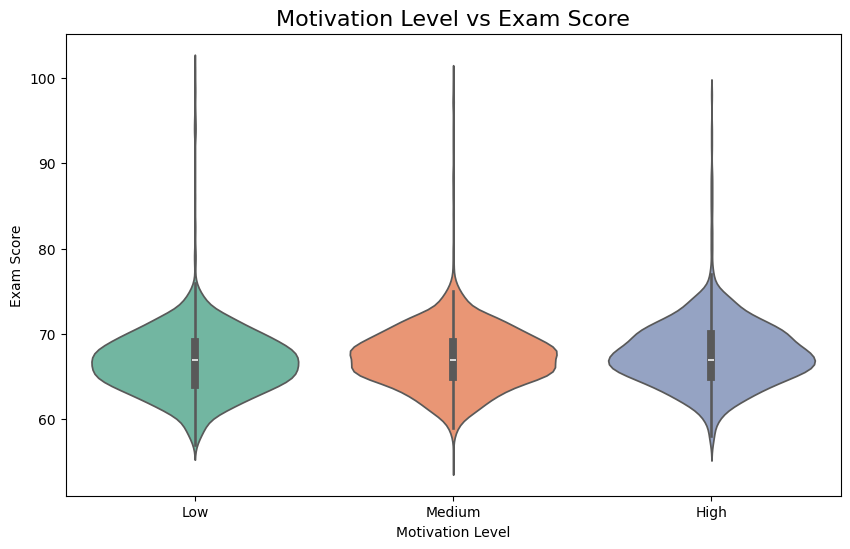

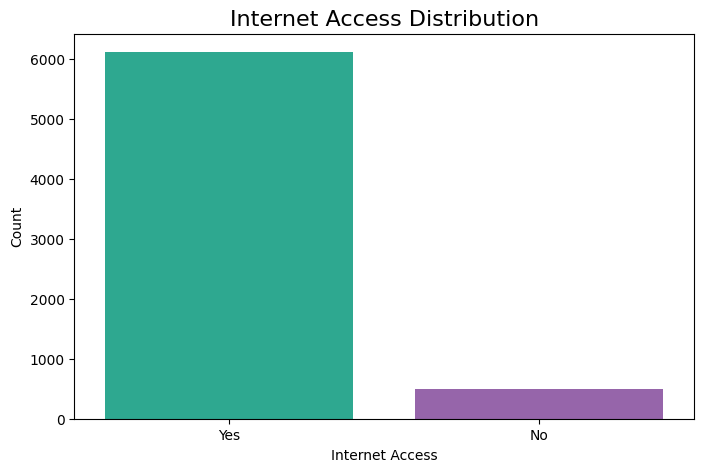

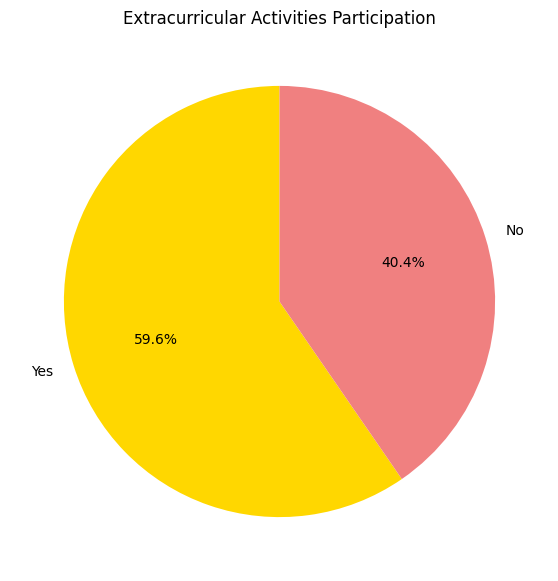

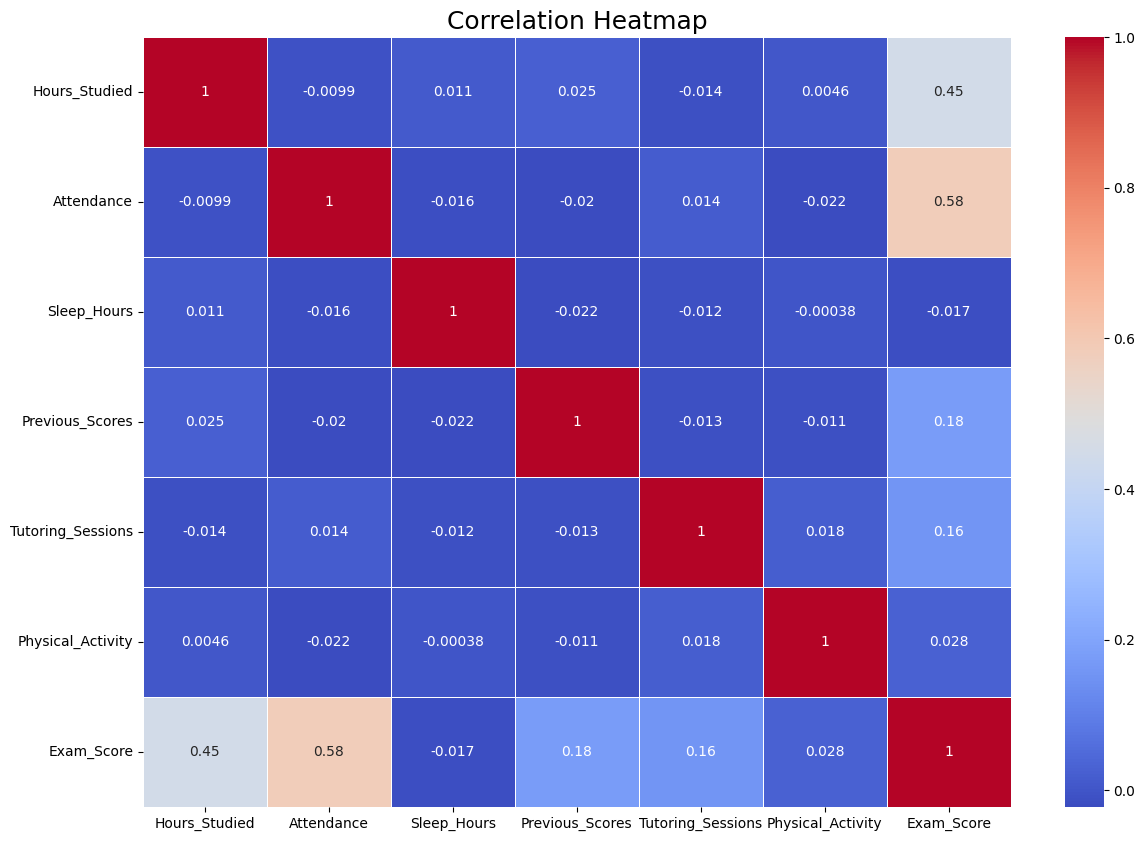

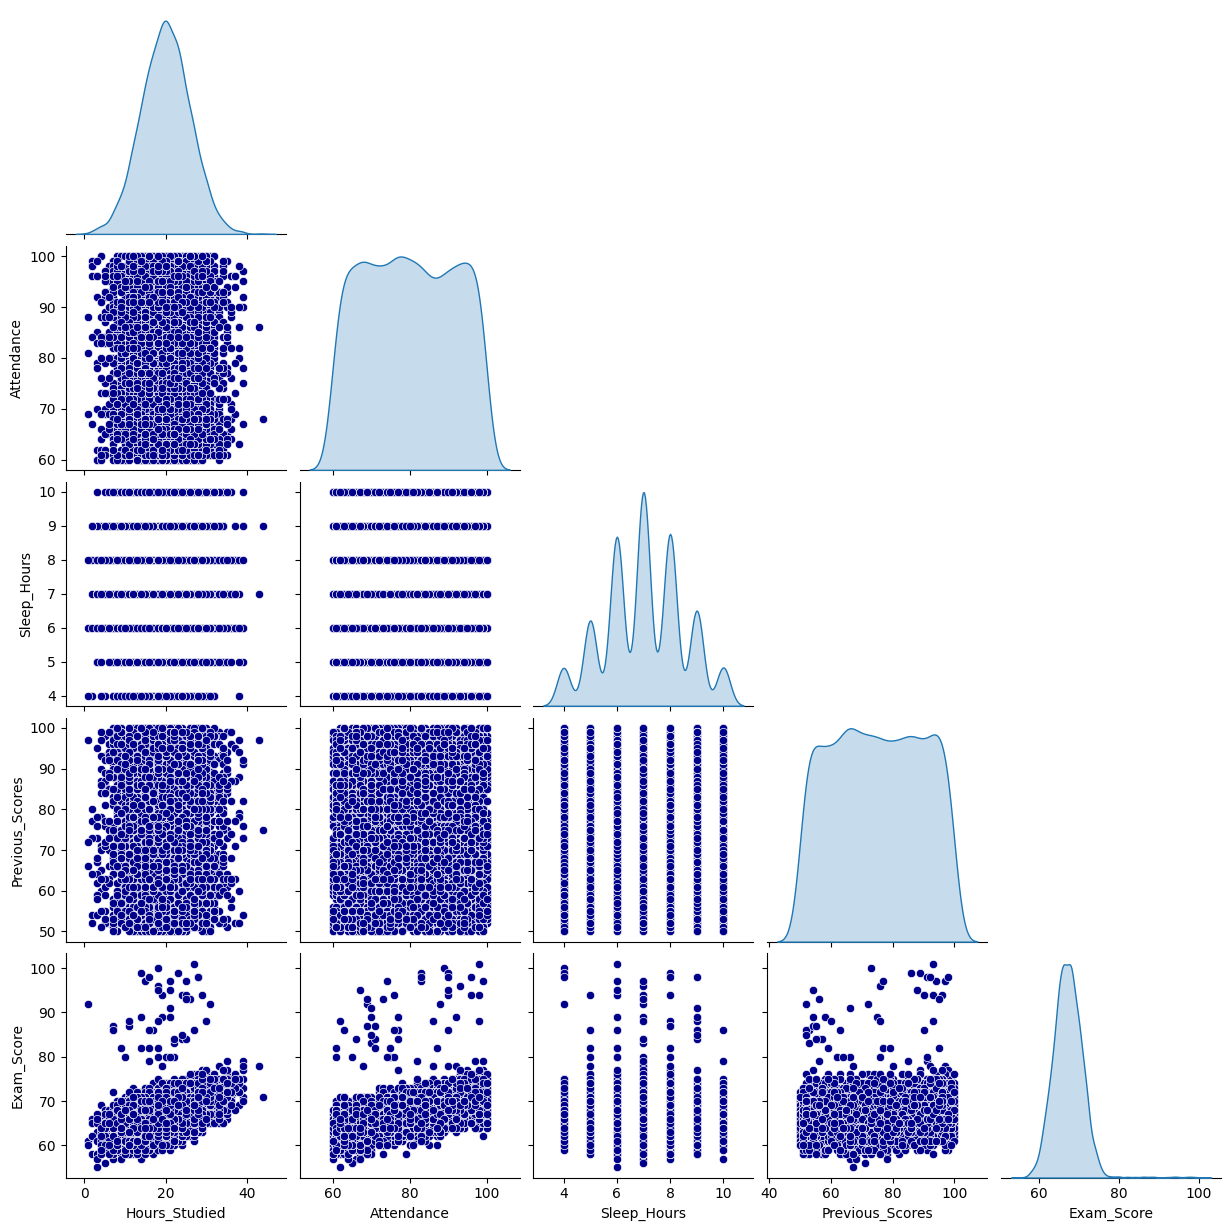

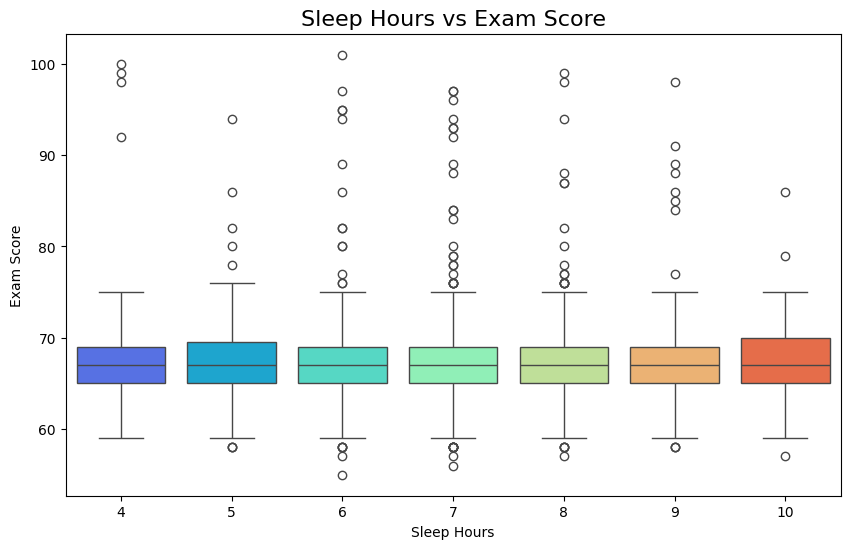

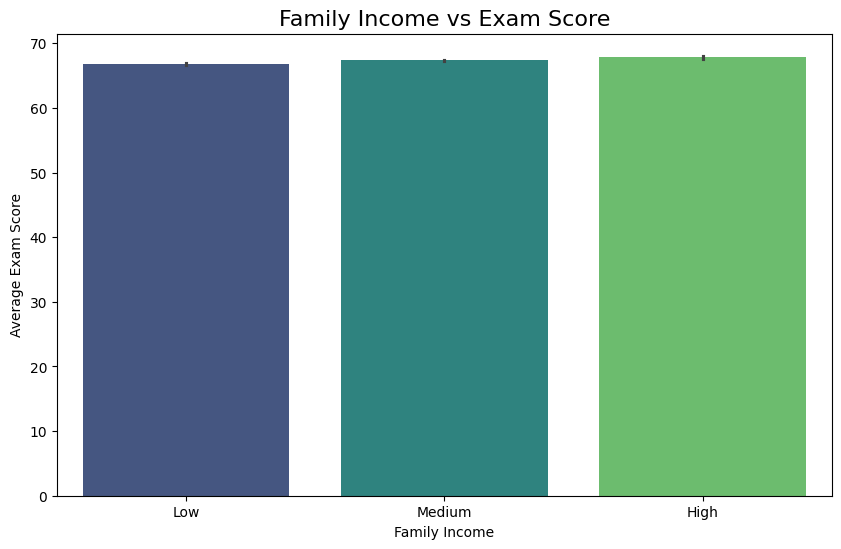

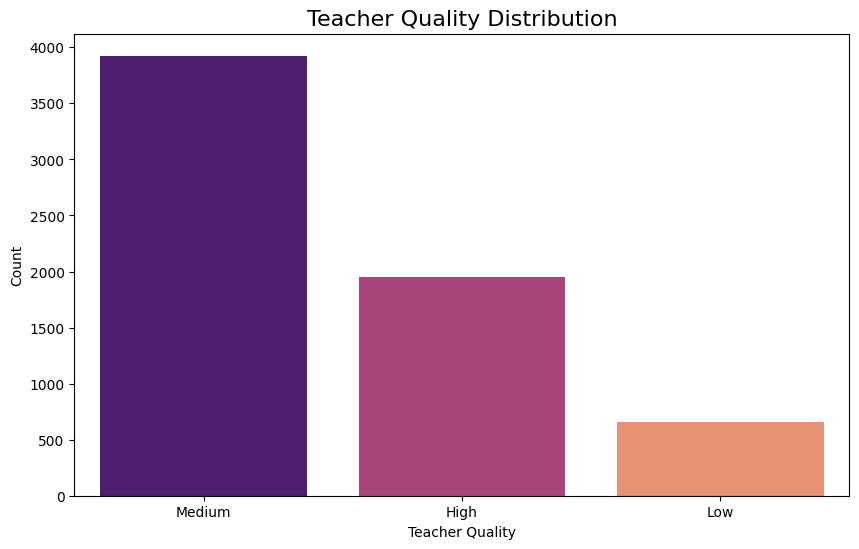

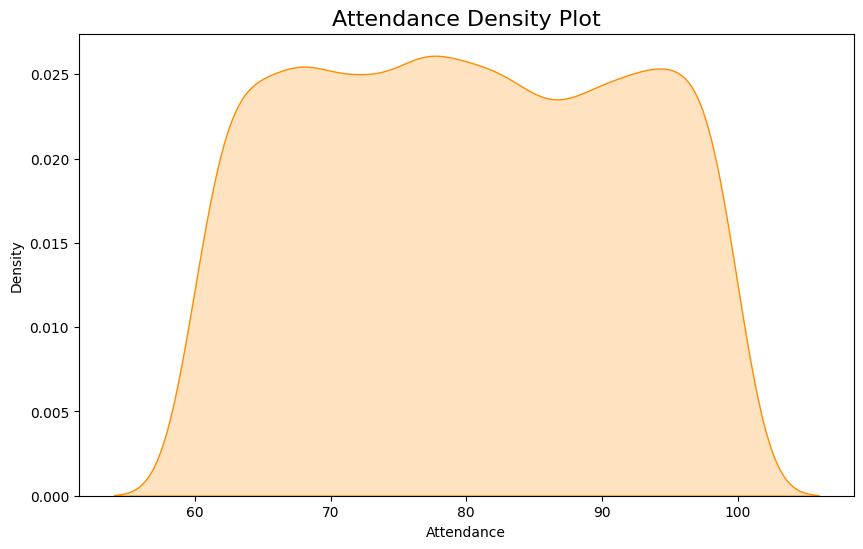

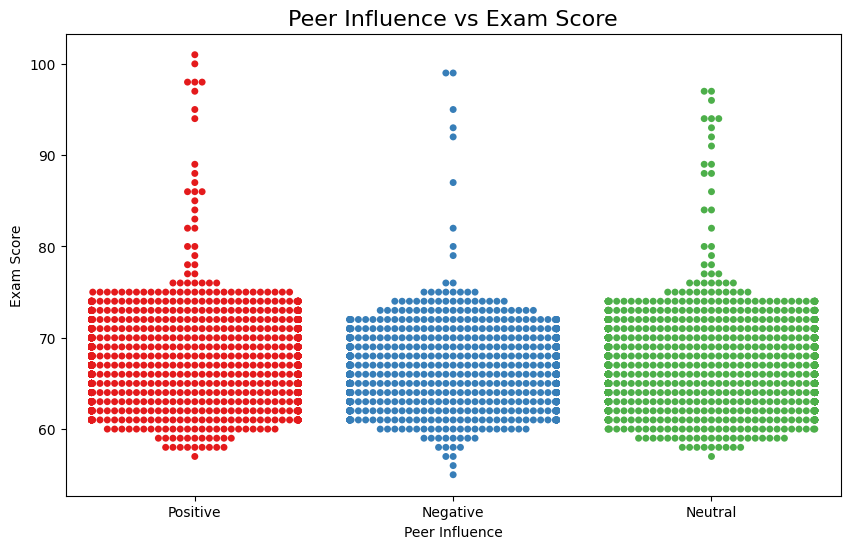

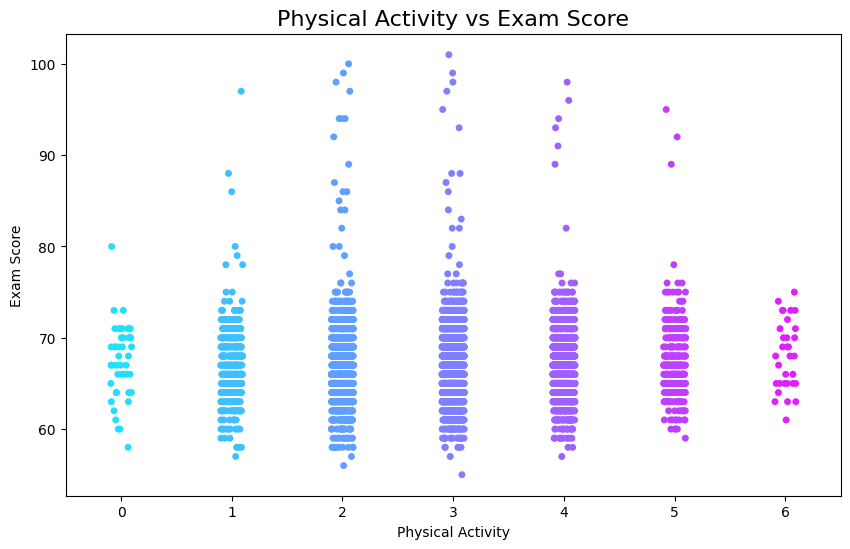

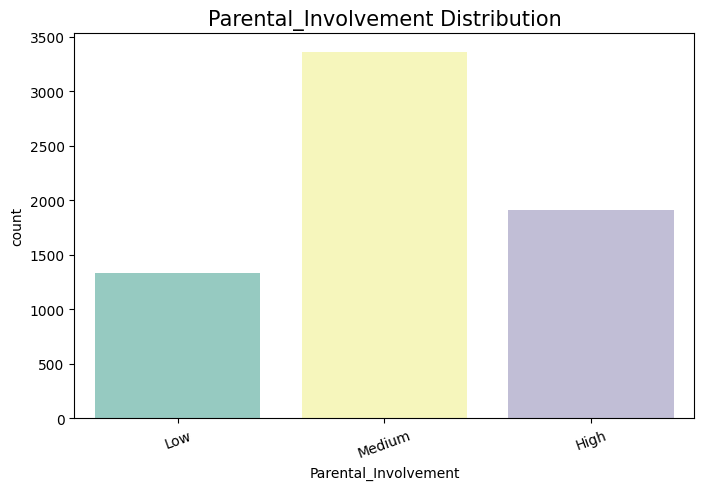

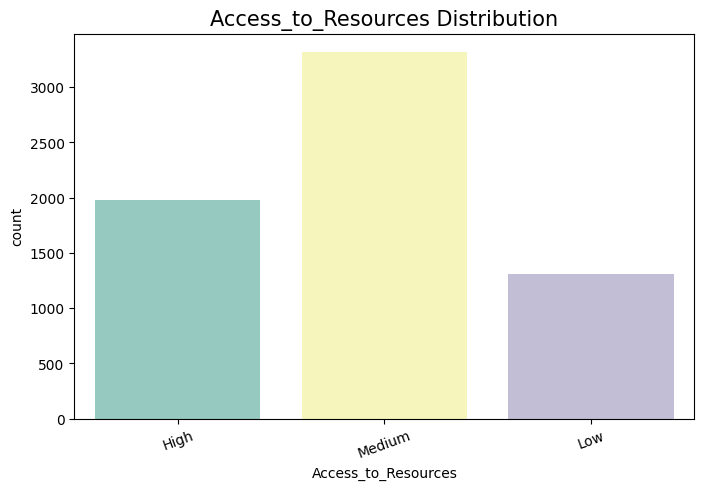

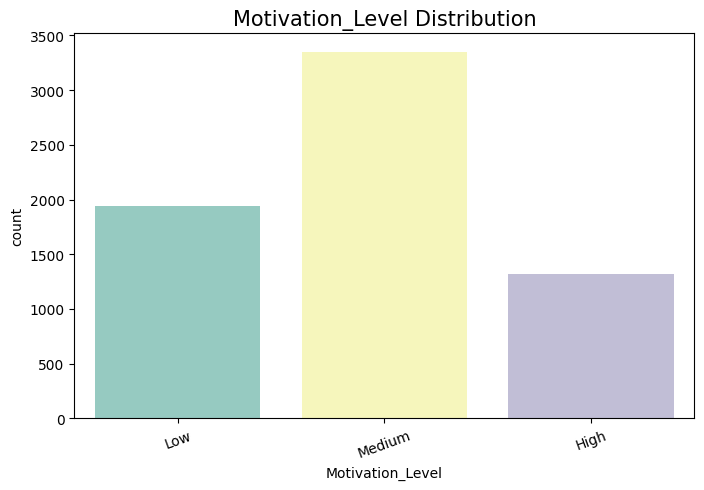

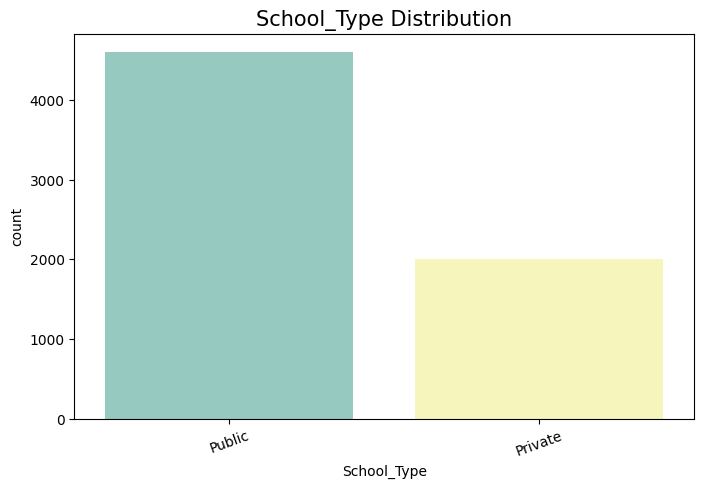

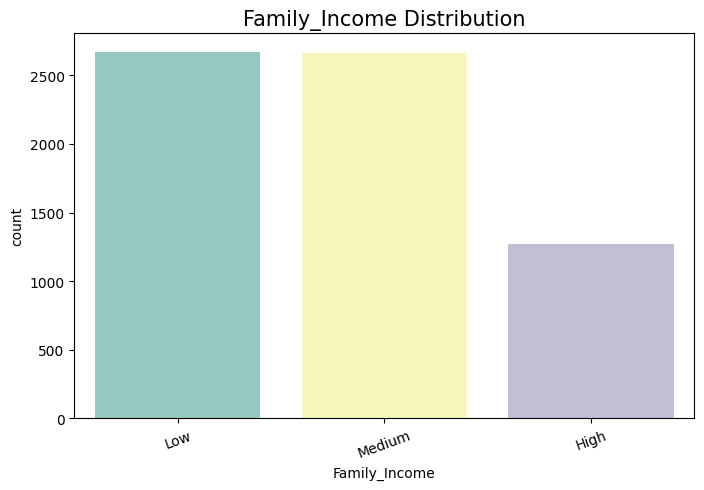

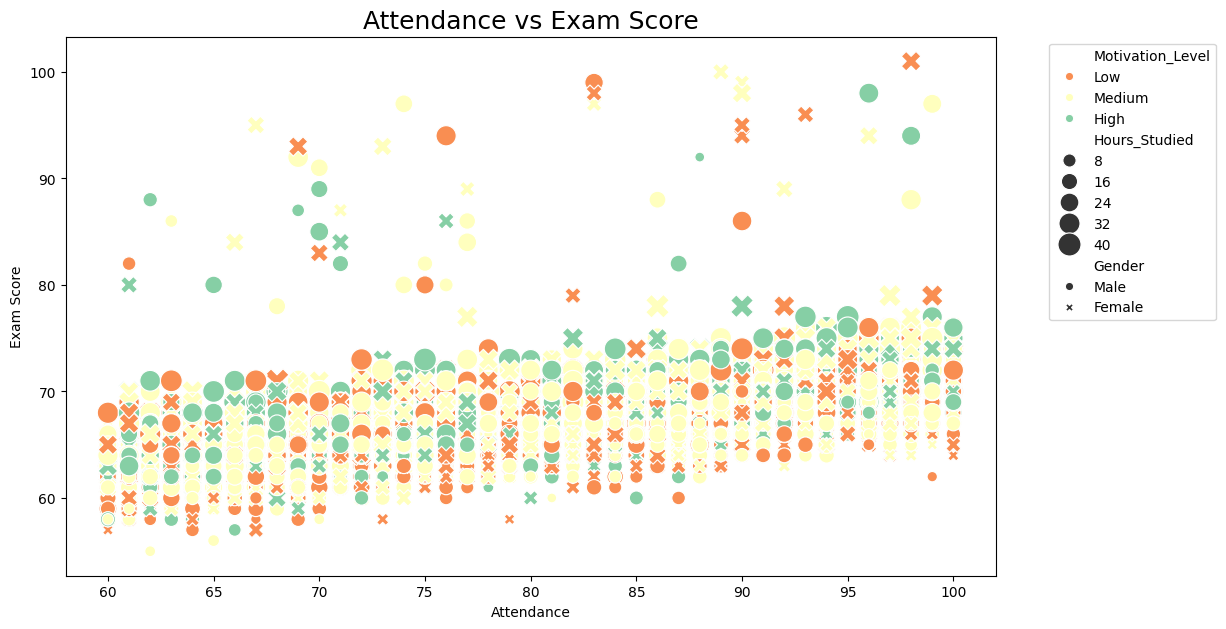

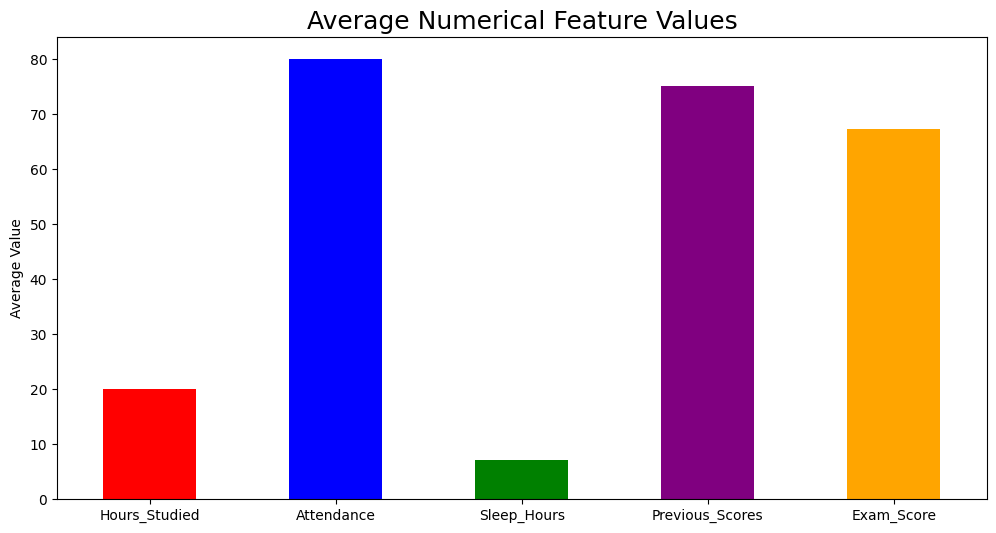

In [14]:
# ==========================================
# 1. HISTOGRAM - Exam Score Distribution
# ==========================================
plt.figure(figsize=(10,6))
sns.histplot(
    df['Exam_Score'],
    bins=20,
    kde=True,
    color='royalblue'
)

plt.title("Distribution of Exam Scores", fontsize=16)
plt.xlabel("Exam Score")
plt.ylabel("Frequency")
plt.show()

# ==========================================
# 2. COUNT PLOT - Gender Distribution
# ==========================================
plt.figure(figsize=(8,5))
sns.countplot(
    x='Gender',
    data=df,
    palette=['#ff6b6b', '#4ecdc4']
)

plt.title("Gender Distribution", fontsize=16)
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

# ==========================================
# 3. BARPLOT - Average Exam Score by Gender
# ==========================================
plt.figure(figsize=(8,5))
sns.barplot(
    x='Gender',
    y='Exam_Score',
    data=df,
    palette=['purple', 'orange']
)

plt.title("Average Exam Score by Gender", fontsize=16)
plt.xlabel("Gender")
plt.ylabel("Average Exam Score")
plt.show()

# ==========================================
# 4. BOXPLOT - Exam Score vs School Type
# ==========================================
plt.figure(figsize=(10,6))
sns.boxplot(
    x='School_Type',
    y='Exam_Score',
    data=df,
    palette=['#3498db', '#2ecc71', '#e74c3c']
)

plt.title("Exam Score by School Type", fontsize=16)
plt.xlabel("School Type")
plt.ylabel("Exam Score")
plt.show()

# ==========================================
# 5. SCATTER PLOT - Hours Studied vs Exam Score
# ==========================================
plt.figure(figsize=(10,6))
sns.scatterplot(
    x='Hours_Studied',
    y='Exam_Score',
    hue='Gender',
    data=df,
    palette=['red', 'blue'],
    s=100
)

plt.title("Hours Studied vs Exam Score", fontsize=16)
plt.xlabel("Hours Studied")
plt.ylabel("Exam Score")
plt.show()

# ==========================================
# 6. LINE PLOT - Previous Scores vs Exam Score
# ==========================================
plt.figure(figsize=(10,6))

sorted_df = df.sort_values(by='Previous_Scores')

plt.plot(
    sorted_df['Previous_Scores'],
    sorted_df['Exam_Score'],
    color='green',
    linewidth=2
)

plt.title("Previous Scores vs Exam Score", fontsize=16)
plt.xlabel("Previous Scores")
plt.ylabel("Exam Score")
plt.show()

# ==========================================
# 7. VIOLIN PLOT - Motivation Level vs Exam Score
# ==========================================
plt.figure(figsize=(10,6))
sns.violinplot(
    x='Motivation_Level',
    y='Exam_Score',
    data=df,
    palette='Set2'
)

plt.title("Motivation Level vs Exam Score", fontsize=16)
plt.xlabel("Motivation Level")
plt.ylabel("Exam Score")
plt.show()

# ==========================================
# 8. COUNT PLOT - Internet Access
# ==========================================
plt.figure(figsize=(8,5))
sns.countplot(
    x='Internet_Access',
    data=df,
    palette=['#1abc9c', '#9b59b6']
)

plt.title("Internet Access Distribution", fontsize=16)
plt.xlabel("Internet Access")
plt.ylabel("Count")
plt.show()

# ==========================================
# 9. PIE CHART - Extracurricular Activities
# ==========================================
activity_counts = df['Extracurricular_Activities'].value_counts()

plt.figure(figsize=(7,7))
plt.pie(
    activity_counts,
    labels=activity_counts.index,
    autopct='%1.1f%%',
    colors=['gold', 'lightcoral'],
    startangle=90
)

plt.title("Extracurricular Activities Participation")
plt.show()

# ==========================================
# 10. HEATMAP - Correlation Matrix
# ==========================================

# Select numerical columns
num_cols = df.select_dtypes(include=np.number)

plt.figure(figsize=(14,10))

sns.heatmap(
    num_cols.corr(),
    annot=True,
    cmap='coolwarm',
    linewidths=0.5
)

plt.title("Correlation Heatmap", fontsize=18)
plt.show()

# ==========================================
# 11. PAIRPLOT - Numerical Features
# ==========================================
sns.pairplot(
    df[
        [
            'Hours_Studied',
            'Attendance',
            'Sleep_Hours',
            'Previous_Scores',
            'Exam_Score'
        ]
    ],
    diag_kind='kde',
    corner=True,
    plot_kws={'color':'darkblue'}
)

plt.show()

# ==========================================
# 12. BOXPLOT - Sleep Hours vs Exam Score
# ==========================================
plt.figure(figsize=(10,6))
sns.boxplot(
    x='Sleep_Hours',
    y='Exam_Score',
    data=df,
    palette='rainbow'
)

plt.title("Sleep Hours vs Exam Score", fontsize=16)
plt.xlabel("Sleep Hours")
plt.ylabel("Exam Score")
plt.show()

# ==========================================
# 13. BARPLOT - Family Income vs Exam Score
# ==========================================
plt.figure(figsize=(10,6))
sns.barplot(
    x='Family_Income',
    y='Exam_Score',
    data=df,
    palette='viridis'
)

plt.title("Family Income vs Exam Score", fontsize=16)
plt.xlabel("Family Income")
plt.ylabel("Average Exam Score")
plt.show()

# ==========================================
# 14. COUNT PLOT - Teacher Quality
# ==========================================
plt.figure(figsize=(10,6))
sns.countplot(
    x='Teacher_Quality',
    data=df,
    palette='magma'
)

plt.title("Teacher Quality Distribution", fontsize=16)
plt.xlabel("Teacher Quality")
plt.ylabel("Count")
plt.show()

# ==========================================
# 15. KDE PLOT - Attendance Distribution
# ==========================================
plt.figure(figsize=(10,6))

sns.kdeplot(
    df['Attendance'],
    fill=True,
    color='darkorange'
)

plt.title("Attendance Density Plot", fontsize=16)
plt.xlabel("Attendance")
plt.ylabel("Density")
plt.show()

# ==========================================
# 16. SWARM PLOT - Peer Influence vs Exam Score
# ==========================================
plt.figure(figsize=(10,6))
sns.swarmplot(
    x='Peer_Influence',
    y='Exam_Score',
    data=df,
    palette='Set1'
)

plt.title("Peer Influence vs Exam Score", fontsize=16)
plt.xlabel("Peer Influence")
plt.ylabel("Exam Score")
plt.show()

# ==========================================
# 17. STRIP PLOT - Physical Activity vs Exam Score
# ==========================================
plt.figure(figsize=(10,6))
sns.stripplot(
    x='Physical_Activity',
    y='Exam_Score',
    data=df,
    palette='cool',
    jitter=True
)

plt.title("Physical Activity vs Exam Score", fontsize=16)
plt.xlabel("Physical Activity")
plt.ylabel("Exam Score")
plt.show()

# ==========================================
# 18. CATEGORICAL FEATURE DISTRIBUTIONS
# ==========================================

categorical_cols = [
    'Parental_Involvement',
    'Access_to_Resources',
    'Motivation_Level',
    'School_Type',
    'Family_Income'
]

for col in categorical_cols:
    
    plt.figure(figsize=(8,5))
    
    sns.countplot(
        x=col,
        data=df,
        palette='Set3'
    )
    
    plt.title(f"{col} Distribution", fontsize=15)
    plt.xticks(rotation=20)
    plt.show()

# ==========================================
# 19. MULTI COLOR SCATTERPLOT
# ==========================================
plt.figure(figsize=(12,7))

sns.scatterplot(
    x='Attendance',
    y='Exam_Score',
    hue='Motivation_Level',
    style='Gender',
    size='Hours_Studied',
    palette='Spectral',
    data=df,
    sizes=(50,300)
)

plt.title("Attendance vs Exam Score", fontsize=18)
plt.xlabel("Attendance")
plt.ylabel("Exam Score")
plt.legend(bbox_to_anchor=(1.05,1), loc='upper left')
plt.show()

# ==========================================
# 20. FINAL SUMMARY VISUALIZATION
# ==========================================

plt.figure(figsize=(12,6))

top_features = [
    'Hours_Studied',
    'Attendance',
    'Sleep_Hours',
    'Previous_Scores',
    'Exam_Score'
]

df[top_features].mean().plot(
    kind='bar',
    color=['red','blue','green','purple','orange']
)

plt.title("Average Numerical Feature Values", fontsize=18)
plt.ylabel("Average Value")
plt.xticks(rotation=0)
plt.show()


## Feature engineering


Target Value Counts:
Target
1    6539
0      68
Name: count, dtype: int64

Numerical Columns:
Index(['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores',
       'Tutoring_Sessions', 'Physical_Activity'],
      dtype='object')

Categorical Columns:
Index(['Parental_Involvement', 'Access_to_Resources',
       'Extracurricular_Activities', 'Motivation_Level', 'Internet_Access',
       'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence',
       'Learning_Disabilities', 'Parental_Education_Level',
       'Distance_from_Home', 'Gender'],
      dtype='object')

Training Shape: (5285, 19)
Testing Shape : (1322, 19)


MODEL : Logistic Regression

Accuracy Score : 0.9947

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.57      0.70        14
           1       1.00      1.00      1.00      1308

    accuracy                           0.99      1322
   macro avg       0.94      0.79      0.85      1322
weigh

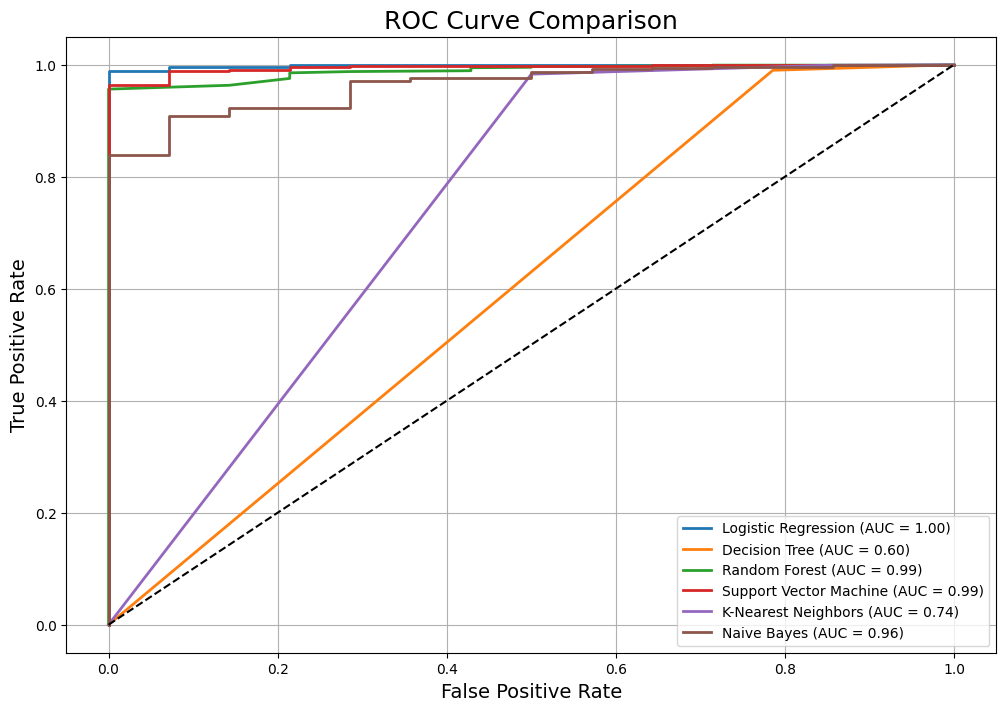



FINAL MODEL COMPARISON
                    Model  Accuracy   ROC_AUC
0     Logistic Regression  0.994705  0.998253
1           Decision Tree  0.981846  0.602173
2           Random Forest  0.989410  0.988396
3  Support Vector Machine  0.990166  0.994921
4     K-Nearest Neighbors  0.989410  0.742600
5             Naive Bayes  0.978820  0.962811

Sorted Results:
                    Model  Accuracy   ROC_AUC
0     Logistic Regression  0.994705  0.998253
3  Support Vector Machine  0.990166  0.994921
2           Random Forest  0.989410  0.988396
5             Naive Bayes  0.978820  0.962811
4     K-Nearest Neighbors  0.989410  0.742600
1           Decision Tree  0.981846  0.602173


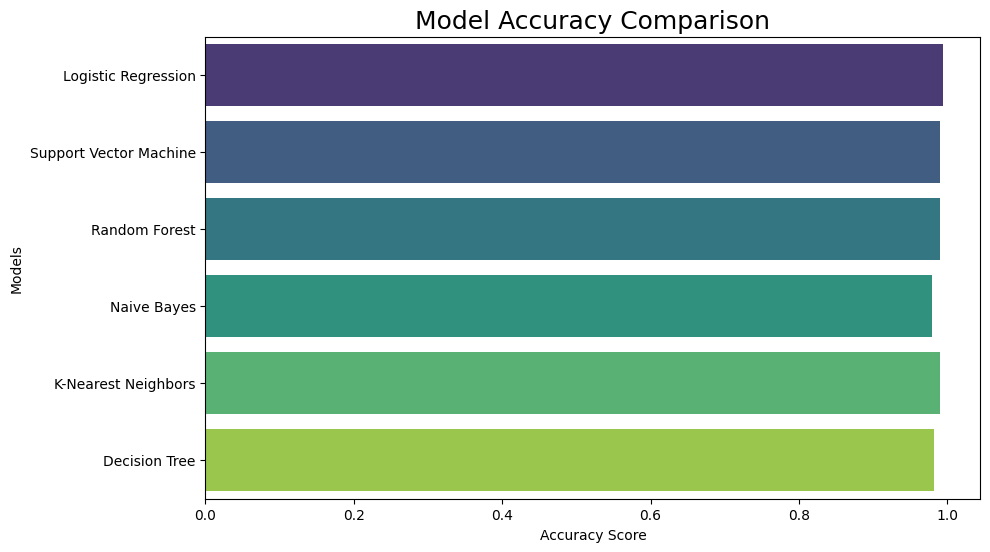

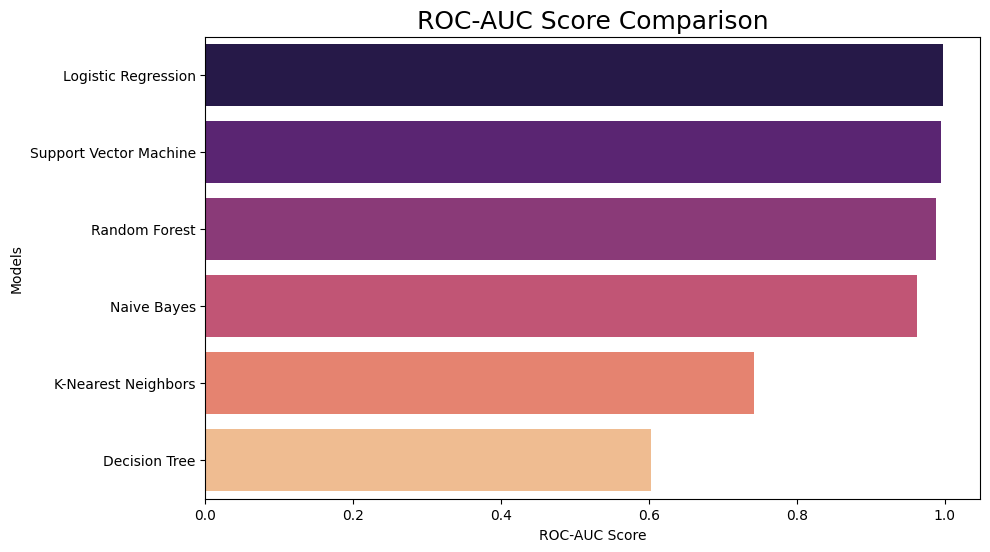



BEST MODEL
Model       Logistic Regression
Accuracy               0.994705
ROC_AUC                0.998253
Name: 0, dtype: object


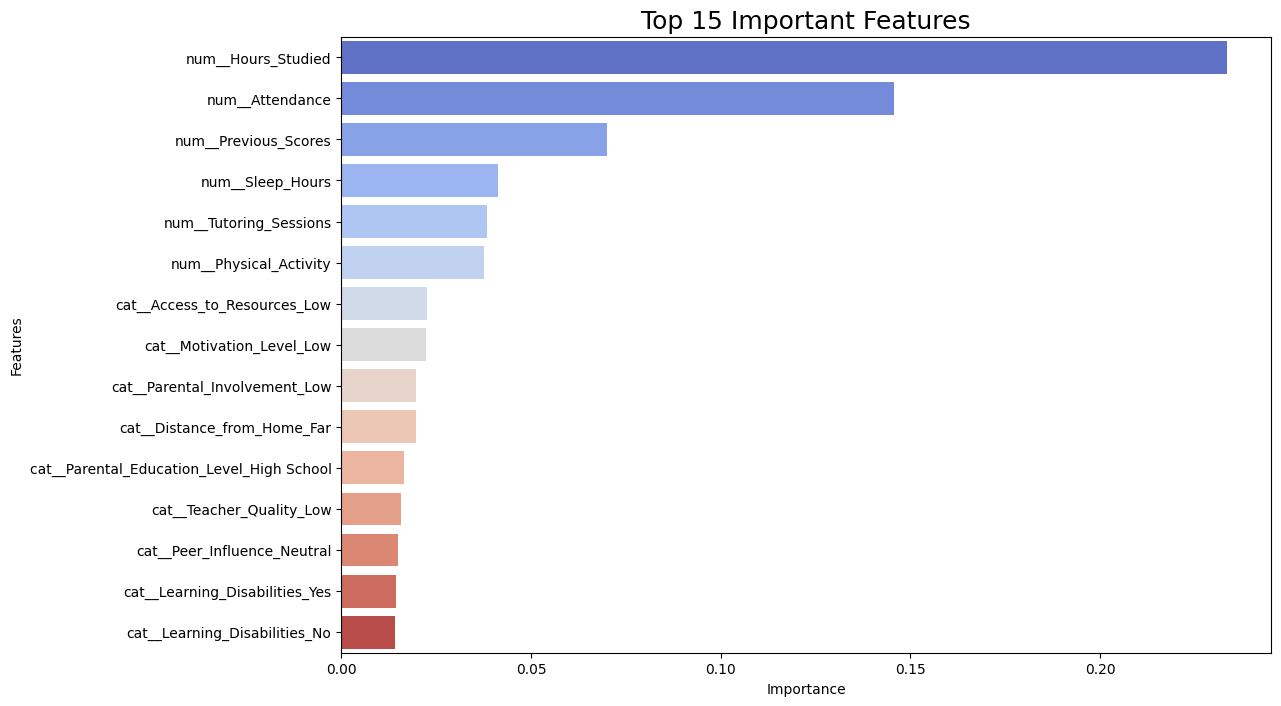

In [15]:
# Train Test Split
from sklearn.model_selection import train_test_split

# Preprocessing
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder
)

# Machine Learning Algorithms
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    roc_auc_score
)



df['Target'] = np.where(df['Exam_Score'] >= 60, 1, 0)

print("\nTarget Value Counts:")
print(df['Target'].value_counts())

# =========================================================
# 5. DEFINE FEATURES AND TARGET
# =========================================================

X = df.drop(['Exam_Score', 'Target'], axis=1)

y = df['Target']

# =========================================================
# 6. IDENTIFY COLUMN TYPES
# =========================================================

numerical_columns = X.select_dtypes(
    include=['int64', 'float64']
).columns

categorical_columns = X.select_dtypes(
    include=['object']
).columns

print("\nNumerical Columns:")
print(numerical_columns)

print("\nCategorical Columns:")
print(categorical_columns)

# =========================================================
# 7. TRAIN TEST SPLIT
# =========================================================
# IMPORTANT:
# Split BEFORE preprocessing to avoid DATA LEAKAGE
# =========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining Shape:", X_train.shape)
print("Testing Shape :", X_test.shape)

# =========================================================
# 8. PREPROCESSING PIPELINES
# =========================================================

# Numerical Pipeline
numerical_pipeline = Pipeline([
    
    ('imputer', SimpleImputer(strategy='median')),
    
    ('scaler', StandardScaler())
])

# Categorical Pipeline
categorical_pipeline = Pipeline([
    
    ('imputer', SimpleImputer(strategy='most_frequent')),
    
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

# Combine Pipelines
preprocessor = ColumnTransformer([
    
    ('num', numerical_pipeline, numerical_columns),
    
    ('cat', categorical_pipeline, categorical_columns)
])

# =========================================================
# 9. DEFINE MACHINE LEARNING MODELS
# =========================================================

models = {

    "Logistic Regression": LogisticRegression(),

    "Decision Tree": DecisionTreeClassifier(
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ),

    "Support Vector Machine": SVC(
        probability=True
    ),

    "K-Nearest Neighbors": KNeighborsClassifier(),

    "Naive Bayes": GaussianNB()
}

# =========================================================
# 10. MODEL TRAINING & EVALUATION
# =========================================================

results = []

# ROC Curve Figure
plt.figure(figsize=(12,8))

# =========================================================
# LOOP THROUGH EACH MODEL
# =========================================================

for model_name, model in models.items():

    print("\n")
    print("="*60)
    print(f"MODEL : {model_name}")
    print("="*60)

    # =====================================================
    # Special Handling for GaussianNB
    # =====================================================

    if model_name == "Naive Bayes":

        # Fit and Transform Training Data
        X_train_processed = preprocessor.fit_transform(X_train)

        # Transform Testing Data
        X_test_processed = preprocessor.transform(X_test)

        # Convert sparse matrix to dense ONLY IF NEEDED
        if hasattr(X_train_processed, "toarray"):
            X_train_processed = X_train_processed.toarray()

        if hasattr(X_test_processed, "toarray"):
            X_test_processed = X_test_processed.toarray()

        # Train Model
        model.fit(X_train_processed, y_train)

        # Predictions
        y_pred = model.predict(X_test_processed)

        # Probability Predictions
        y_prob = model.predict_proba(X_test_processed)[:,1]

    else:

        # Create Full Pipeline
        pipeline = Pipeline([
            
            ('preprocessor', preprocessor),
            
            ('model', model)
        ])

        # Train Model
        pipeline.fit(X_train, y_train)

        # Predictions
        y_pred = pipeline.predict(X_test)

        # Probability Predictions
        y_prob = pipeline.predict_proba(X_test)[:,1]

    # =====================================================
    # ACCURACY
    # =====================================================

    accuracy = accuracy_score(y_test, y_pred)

    print(f"\nAccuracy Score : {accuracy:.4f}")

    # =====================================================
    # CLASSIFICATION REPORT
    # =====================================================

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred))

    # =====================================================
    # CONFUSION MATRIX
    # =====================================================

    cm = confusion_matrix(y_test, y_pred)

    print("Confusion Matrix:")
    print(cm)

    # =====================================================
    # ROC AUC SCORE
    # =====================================================

    roc_auc = roc_auc_score(y_test, y_prob)

    print(f"\nROC-AUC Score : {roc_auc:.4f}")

    # =====================================================
    # STORE RESULTS
    # =====================================================

    results.append({
        'Model': model_name,
        'Accuracy': accuracy,
        'ROC_AUC': roc_auc
    })

    # =====================================================
    # ROC CURVE
    # =====================================================

    fpr, tpr, thresholds = roc_curve(
        y_test,
        y_prob
    )

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f'{model_name} (AUC = {roc_auc:.2f})'
    )

# =========================================================
# 11. FINAL ROC CURVE PLOT
# =========================================================

plt.plot(
    [0,1],
    [0,1],
    linestyle='--',
    color='black'
)

plt.title(
    "ROC Curve Comparison",
    fontsize=18
)

plt.xlabel(
    "False Positive Rate",
    fontsize=14
)

plt.ylabel(
    "True Positive Rate",
    fontsize=14
)

plt.legend()

plt.grid(True)

plt.show()

# =========================================================
# 12. RESULTS DATAFRAME
# =========================================================

results_df = pd.DataFrame(results)

print("\n")
print("="*60)
print("FINAL MODEL COMPARISON")
print("="*60)

print(results_df)

# =========================================================
# 13. SORT RESULTS
# =========================================================

results_df = results_df.sort_values(
    by='ROC_AUC',
    ascending=False
)

print("\nSorted Results:")
print(results_df)

# =========================================================
# 14. ACCURACY VISUALIZATION
# =========================================================

plt.figure(figsize=(10,6))

sns.barplot(
    x='Accuracy',
    y='Model',
    data=results_df,
    palette='viridis'
)

plt.title(
    "Model Accuracy Comparison",
    fontsize=18
)

plt.xlabel("Accuracy Score")

plt.ylabel("Models")

plt.show()

# =========================================================
# 15. ROC AUC VISUALIZATION
# =========================================================

plt.figure(figsize=(10,6))

sns.barplot(
    x='ROC_AUC',
    y='Model',
    data=results_df,
    palette='magma'
)

plt.title(
    "ROC-AUC Score Comparison",
    fontsize=18
)

plt.xlabel("ROC-AUC Score")

plt.ylabel("Models")

plt.show()

# =========================================================
# 16. BEST MODEL
# =========================================================

best_model = results_df.iloc[0]

print("\n")
print("="*60)
print("BEST MODEL")
print("="*60)

print(best_model)

# =========================================================
# 17. FEATURE IMPORTANCE
# =========================================================
# Random Forest Feature Importance
# =========================================================

# Create Random Forest Pipeline
rf_pipeline = Pipeline([
    
    ('preprocessor', preprocessor),
    
    ('model', RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ))
])

# Train
rf_pipeline.fit(X_train, y_train)

# Get Feature Names
encoded_features = rf_pipeline.named_steps[
    'preprocessor'
].get_feature_names_out()

# Get Feature Importances
importances = rf_pipeline.named_steps[
    'model'
].feature_importances_

# Create DataFrame
feature_importance_df = pd.DataFrame({

    'Feature': encoded_features,
    
    'Importance': importances
})

# Sort
feature_importance_df = feature_importance_df.sort_values(
    by='Importance',
    ascending=False
)

# Top 15 Features
top_features = feature_importance_df.head(15)

# =========================================================
# FEATURE IMPORTANCE PLOT
# =========================================================

plt.figure(figsize=(12,8))

sns.barplot(
    x='Importance',
    y='Feature',
    data=top_features,
    palette='coolwarm'
)

plt.title(
    "Top 15 Important Features",
    fontsize=18
)

plt.xlabel("Importance")

plt.ylabel("Features")

plt.show()


## Thank you..pls upvote!!!!!!!!!!!!